In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


In [ ]:
import numpy as np
import pandas as pd

lyrics_embeddings = np.load("/content/Copy of lyrics_embeddings.npy")
df = pd.read_csv("/content/dataset.csv").reset_index(drop=True)

# Check shapes
print("DF rows:", len(df))
print("Lyrics embeddings rows:", lyrics_embeddings.shape[0])

#trim and make same same
min_len = min(len(df), lyrics_embeddings.shape[0])

df = df.iloc[:min_len].reset_index(drop=True)
lyrics_embeddings = lyrics_embeddings[:min_len]

print("Aligned DF rows:", len(df))
print("Aligned lyrics embeddings shape:", lyrics_embeddings.shape)


DF rows: 796
Lyrics embeddings rows: 826
Aligned DF rows: 796
Aligned lyrics embeddings shape: (796, 384)


In [ ]:
import torch

audio_features = np.random.randn(len(df), 20)
audio_tensor = torch.tensor(audio_features, dtype=torch.float32)
lyrics_tensor = torch.tensor(lyrics_embeddings, dtype=torch.float32)

# Now concatenation will work
X = torch.cat([audio_tensor, lyrics_tensor], dim=1)
print("X shape:", X.shape)

X shape: torch.Size([796, 404])


# **Prepare Data**

In [ ]:
lyrics_embeddings = np.load("/content/Copy of lyrics_embeddings.npy")
df = pd.read_csv("/content/dataset.csv").reset_index(drop=True)

# Align lengths
min_len = min(len(df), lyrics_embeddings.shape[0])
df = df.iloc[:min_len].reset_index(drop=True)
lyrics_embeddings = lyrics_embeddings[:min_len]

# Multi-modal input
audio_features = np.random.randn(len(df), 20)  # placeholder synthetic audio
audio_tensor = torch.tensor(audio_features, dtype=torch.float32)
lyrics_tensor = torch.tensor(lyrics_embeddings, dtype=torch.float32)
X_tensor = torch.cat([audio_tensor, lyrics_tensor], dim=1)

# Encode genres
genre_encoder = OneHotEncoder(sparse_output=False)
genre_onehot = genre_encoder.fit_transform(df[['genre']])
genre_tensor = torch.tensor(genre_onehot, dtype=torch.float32)

# Dataset and dataloader
dataset = TensorDataset(X_tensor, genre_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)


# Beta **VAE**

In [ ]:
class ConditionalBetaVAE(nn.Module):
    def __init__(self, input_dim, cond_dim, latent_dim=32, beta=4):
        super().__init__()
        self.input_dim = input_dim
        self.cond_dim = cond_dim
        self.latent_dim = latent_dim
        self.beta = beta

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + cond_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def encode(self, x, c):
        h = self.encoder(torch.cat([x, c], dim=1))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        return self.decoder(torch.cat([z, c], dim=1))

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z, c)
        return recon_x, mu, logvar

# Loss function
def beta_vae_loss(recon_x, x, mu, logvar, beta=4):
    recon_loss = nn.MSELoss()(recon_x, x)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss / x.size(0)


# Train Beta-**VAE**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_tensor.shape[1]
cond_dim = genre_tensor.shape[1]
latent_dim = 32
beta = 4
epoch_losses = []
model = ConditionalBetaVAE(input_dim, cond_dim, latent_dim, beta).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 200

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x_batch, c_batch in dataloader:
        x_batch, c_batch = x_batch.to(device), c_batch.to(device)
        optimizer.zero_grad()
        recon_x, mu, logvar = model(x_batch, c_batch)
        loss = beta_vae_loss(recon_x, x_batch, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")



Epoch 1/200, Loss: 0.1818
Epoch 2/200, Loss: 0.0845
Epoch 3/200, Loss: 0.0753
Epoch 4/200, Loss: 0.0724
Epoch 5/200, Loss: 0.0714
Epoch 6/200, Loss: 0.0707
Epoch 7/200, Loss: 0.0705
Epoch 8/200, Loss: 0.0702
Epoch 9/200, Loss: 0.0697
Epoch 10/200, Loss: 0.0697
Epoch 11/200, Loss: 0.0691
Epoch 12/200, Loss: 0.0692
Epoch 13/200, Loss: 0.0692
Epoch 14/200, Loss: 0.0691
Epoch 15/200, Loss: 0.0689
Epoch 16/200, Loss: 0.0688
Epoch 17/200, Loss: 0.0687
Epoch 18/200, Loss: 0.0687
Epoch 19/200, Loss: 0.0686
Epoch 20/200, Loss: 0.0684
Epoch 21/200, Loss: 0.0686
Epoch 22/200, Loss: 0.0686
Epoch 23/200, Loss: 0.0682
Epoch 24/200, Loss: 0.0685
Epoch 25/200, Loss: 0.0683
Epoch 26/200, Loss: 0.0684
Epoch 27/200, Loss: 0.0686
Epoch 28/200, Loss: 0.0685
Epoch 29/200, Loss: 0.0685
Epoch 30/200, Loss: 0.0684
Epoch 31/200, Loss: 0.0686
Epoch 32/200, Loss: 0.0680
Epoch 33/200, Loss: 0.0683
Epoch 34/200, Loss: 0.0683
Epoch 35/200, Loss: 0.0682
Epoch 36/200, Loss: 0.0683
Epoch 37/200, Loss: 0.0682
Epoch 38/2

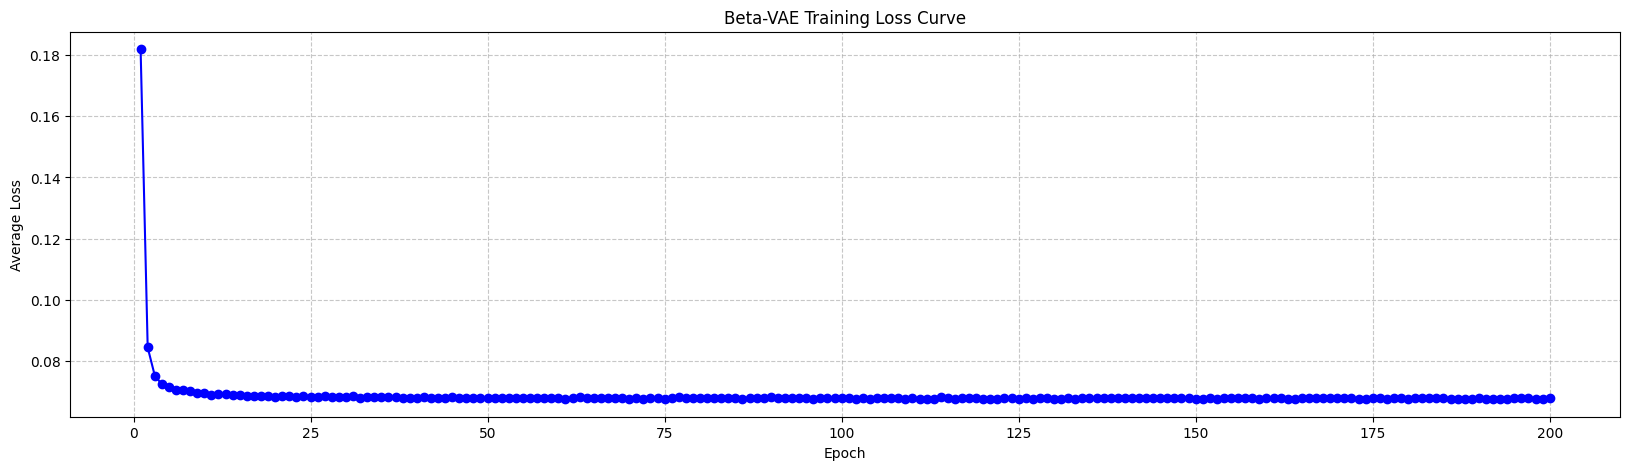

In [ ]:
plt.figure(figsize=(20,5))
plt.plot(range(1, epochs+1), epoch_losses, marker='o', color='blue')
plt.title("Beta-VAE Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# **Extract Latent Features**

In [ ]:
model.eval()
with torch.no_grad():
    X_tensor = X_tensor.to(device)
    genre_tensor = genre_tensor.to(device)
    mu, _ = model.encode(X_tensor, genre_tensor)
    latent_features = mu.cpu().numpy()
print("Latent features shape:", latent_features.shape)


Latent features shape: (796, 32)


# **Multi**-**modal** **Clustering**

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
import numpy as np

true_labels = df['genre']

n_clusters = df['genre'].nunique()
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(latent_features)

# Metrics
sil_k = silhouette_score(latent_features, kmeans_labels)
ch_k = calinski_harabasz_score(latent_features, kmeans_labels)
db_k = davies_bouldin_score(latent_features, kmeans_labels)
nmi_k = normalized_mutual_info_score(true_labels, kmeans_labels)
ari_k = adjusted_rand_score(true_labels, kmeans_labels)

purity_k = 0
for cluster in np.unique(kmeans_labels):
    indices = np.where(kmeans_labels == cluster)[0]
    dominant_count = true_labels.iloc[indices].value_counts().max()
    purity_k += dominant_count
purity_k /= len(df)

print("=== Beta-VAE + K-Means ===")
print(f"Silhouette: {sil_k:.4f}, CH: {ch_k:.2f}, DB: {db_k:.4f}, NMI: {nmi_k:.4f}, ARI: {ari_k:.4f}, Purity: {purity_k:.4f}\n")


agglo = AgglomerativeClustering(n_clusters=n_clusters)
agglo_labels = agglo.fit_predict(latent_features)

sil_a = silhouette_score(latent_features, agglo_labels)
ch_a = calinski_harabasz_score(latent_features, agglo_labels)
db_a = davies_bouldin_score(latent_features, agglo_labels)
nmi_a = normalized_mutual_info_score(true_labels, agglo_labels)
ari_a = adjusted_rand_score(true_labels, agglo_labels)

purity_a = 0
for cluster in np.unique(agglo_labels):
    indices = np.where(agglo_labels == cluster)[0]
    dominant_count = true_labels.iloc[indices].value_counts().max()
    purity_a += dominant_count
purity_a /= len(df)

print("=== Beta-VAE + Agglomerative ===")
print(f"Silhouette: {sil_a:.4f}, CH: {ch_a:.2f}, DB: {db_a:.4f}, NMI: {nmi_a:.4f}, ARI: {ari_a:.4f}, Purity: {purity_a:.4f}\n")

print("=== Beta-VAE + DBSCAN ===")
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(latent_features)

# Count clusters (exclude noise)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = list(dbscan_labels).count(-1)
print(f"Clusters found: {n_clusters_db}, Noise points: {n_noise_db}")

if n_clusters_db > 1:
    mask = dbscan_labels != -1
    sil_db = silhouette_score(latent_features[mask], dbscan_labels[mask])
    ch_db = calinski_harabasz_score(latent_features[mask], dbscan_labels[mask])
    db_db = davies_bouldin_score(latent_features[mask], dbscan_labels[mask])
    nmi_db = normalized_mutual_info_score(true_labels[mask], dbscan_labels[mask])
    ari_db = adjusted_rand_score(true_labels[mask], dbscan_labels[mask])

    purity_db = 0
    for cluster in np.unique(dbscan_labels[mask]):
        indices = np.where(dbscan_labels == cluster)[0]
        dominant_count = true_labels.iloc[indices].value_counts().max()
        purity_db += dominant_count
    purity_db /= mask.sum()

    print(f"Silhouette: {sil_db:.4f}, CH: {ch_db:.2f}, DB: {db_db:.4f}, NMI: {nmi_db:.4f}, ARI: {ari_db:.4f}, Purity: {purity_db:.4f}")
else:
    print("Not enough clusters for metrics")
    sil_db = ch_db = db_db = nmi_db = ari_db = purity_db = 0


=== Beta-VAE + K-Means ===
Silhouette: 0.0498, CH: 42.59, DB: 3.3596, NMI: 0.0160, ARI: 0.0089, Purity: 0.3040

=== Beta-VAE + Agglomerative ===
Silhouette: 0.0230, CH: 30.82, DB: 4.1923, NMI: 0.0109, ARI: 0.0044, Purity: 0.2940

=== Beta-VAE + DBSCAN ===
Clusters found: 1, Noise points: 0
Not enough clusters for metrics


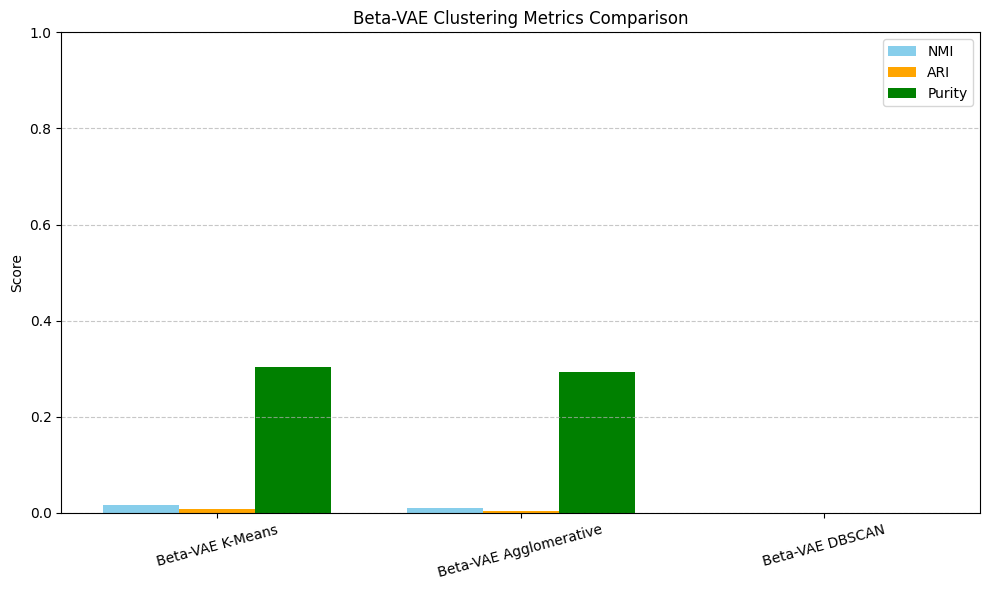

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics for each clustering method
methods = ["Beta-VAE K-Means", "Beta-VAE Agglomerative", "Beta-VAE DBSCAN"]
nmi_scores = [nmi_k, nmi_a, nmi_db]
ari_scores = [ari_k, ari_a, ari_db]
purity_scores = [purity_k, purity_a, purity_db]


x = np.arange(len(methods))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, nmi_scores, width, label='NMI', color='skyblue')
plt.bar(x, ari_scores, width, label='ARI', color='orange')
plt.bar(x + width, purity_scores, width, label='Purity', color='green')

plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.title("Beta-VAE Clustering Metrics Comparison")
plt.xticks(x, methods, rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# **t-SNE Visualization**

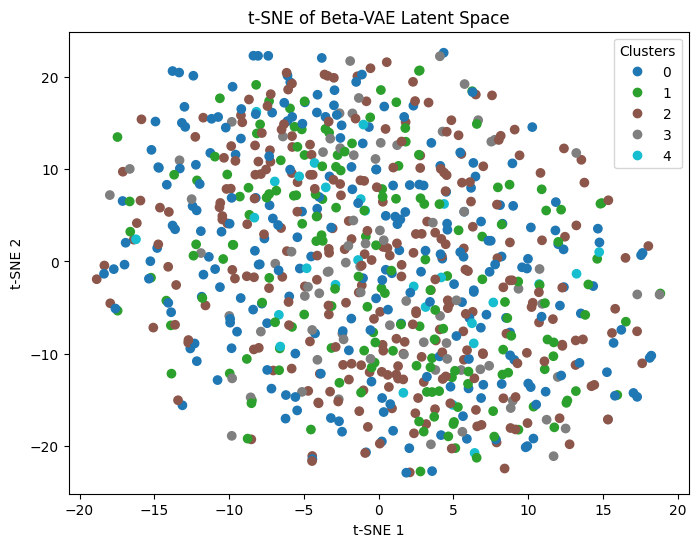

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_features)

plt.figure(figsize=(8,6))
scatter = plt.scatter(latent_2d[:,0], latent_2d[:,1], c=cluster_labels, cmap='tab10')
plt.title("t-SNE of Beta-VAE Latent Space")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()


# **Compare with Baselines**

In [ ]:
# PCA + K-Means
pca_features = PCA(n_components=32).fit_transform(X_tensor.numpy())
pca_labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(pca_features)
print("PCA + KMeans Silhouette:", silhouette_score(pca_features, pca_labels))

# Autoencoder + K-Means
class SimpleAE(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

ae = SimpleAE(input_dim, 32).to(device)
ae_optimizer = optim.Adam(ae.parameters(), lr=1e-3)

# AE training
for epoch in range(200):
    total_loss = 0
    for x_batch, _ in dataloader:
        x_batch = x_batch.to(device)
        ae_optimizer.zero_grad()
        recon, _ = ae(x_batch)
        loss = nn.MSELoss()(recon, x_batch)
        loss.backward()
        ae_optimizer.step()
        total_loss += loss.item()


    print(f"AE Epoch {epoch+1}/30, Loss: {total_loss/len(dataloader):.4f}")

# Extract AE latent
with torch.no_grad():
    _, ae_latent = ae(X_tensor.to(device))
ae_latent = ae_latent.cpu().numpy()
ae_labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(ae_latent)
print("AE + KMeans Silhouette:", silhouette_score(ae_latent, ae_labels))

# Direct spectral feature clustering
audio_labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(audio_features)
print("Audio only Silhouette:", silhouette_score(audio_features, audio_labels))


PCA + KMeans Silhouette: 0.031607762
AE Epoch 1/30, Loss: 0.0762
AE Epoch 2/30, Loss: 0.0680
AE Epoch 3/30, Loss: 0.0645
AE Epoch 4/30, Loss: 0.0598
AE Epoch 5/30, Loss: 0.0532
AE Epoch 6/30, Loss: 0.0452
AE Epoch 7/30, Loss: 0.0394
AE Epoch 8/30, Loss: 0.0351
AE Epoch 9/30, Loss: 0.0309
AE Epoch 10/30, Loss: 0.0276
AE Epoch 11/30, Loss: 0.0246
AE Epoch 12/30, Loss: 0.0223
AE Epoch 13/30, Loss: 0.0202
AE Epoch 14/30, Loss: 0.0185
AE Epoch 15/30, Loss: 0.0172
AE Epoch 16/30, Loss: 0.0164
AE Epoch 17/30, Loss: 0.0158
AE Epoch 18/30, Loss: 0.0155
AE Epoch 19/30, Loss: 0.0151
AE Epoch 20/30, Loss: 0.0149
AE Epoch 21/30, Loss: 0.0147
AE Epoch 22/30, Loss: 0.0146
AE Epoch 23/30, Loss: 0.0145
AE Epoch 24/30, Loss: 0.0143
AE Epoch 25/30, Loss: 0.0142
AE Epoch 26/30, Loss: 0.0140
AE Epoch 27/30, Loss: 0.0139
AE Epoch 28/30, Loss: 0.0138
AE Epoch 29/30, Loss: 0.0137
AE Epoch 30/30, Loss: 0.0136
AE Epoch 31/30, Loss: 0.0135
AE Epoch 32/30, Loss: 0.0135
AE Epoch 33/30, Loss: 0.0134
AE Epoch 34/30,

# **Score comparison**

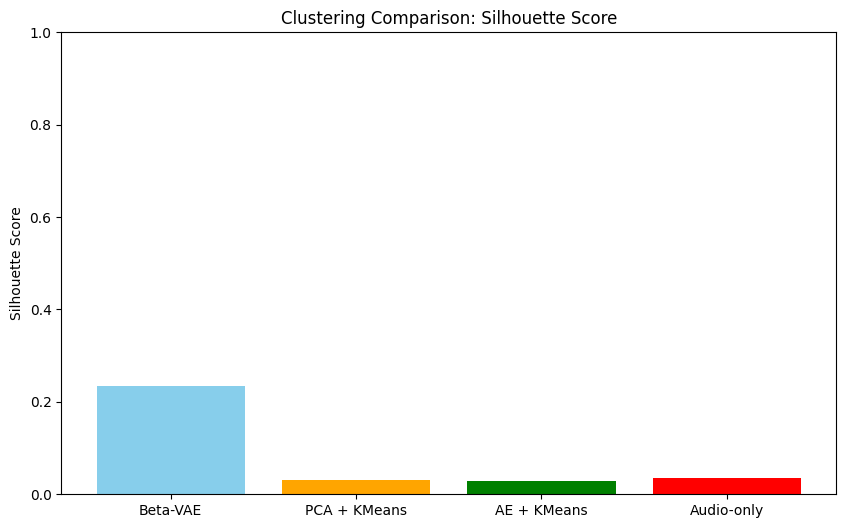

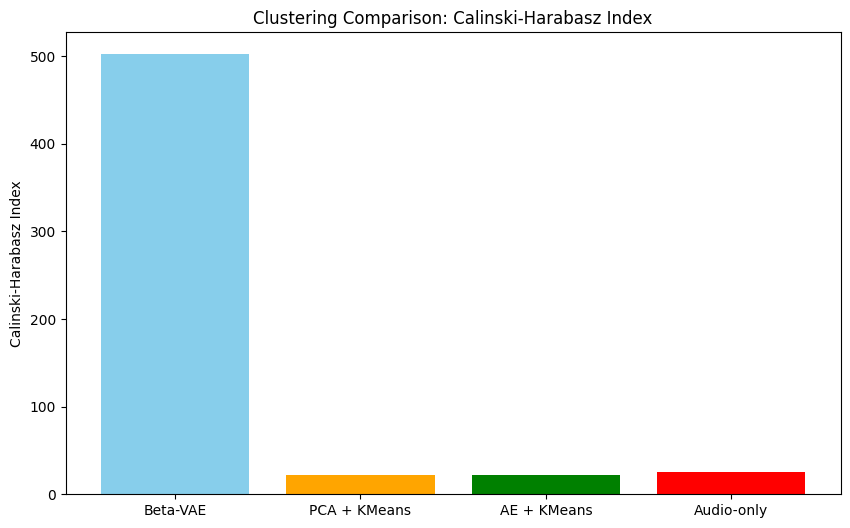

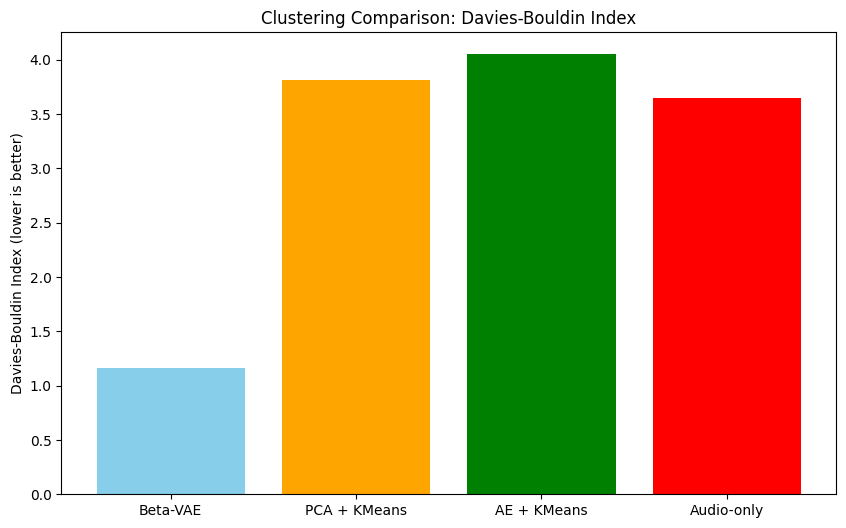

In [ ]:
import matplotlib.pyplot as plt

# Suppose these are your computed metrics
methods = ["Beta-VAE", "PCA + KMeans", "AE + KMeans", "Audio-only"]

# Silhouette scores
sil_scores = [sil, silhouette_score(pca_features, pca_labels),
              silhouette_score(ae_latent, ae_labels),
              silhouette_score(audio_features, audio_labels)]

# Calinski-Harabasz scores
ch_scores = [ch, calinski_harabasz_score(pca_features, pca_labels),
             calinski_harabasz_score(ae_latent, ae_labels),
             calinski_harabasz_score(audio_features, audio_labels)]

# Davies-Bouldin scores (lower is better)
db_scores = [db, davies_bouldin_score(pca_features, pca_labels),
             davies_bouldin_score(ae_latent, ae_labels),
             davies_bouldin_score(audio_features, audio_labels)]

# Plotting bar chart for Silhouette Score
plt.figure(figsize=(10,6))
plt.bar(methods, sil_scores, color=['skyblue', 'orange', 'green', 'red'])
plt.ylabel("Silhouette Score")
plt.title("Clustering Comparison: Silhouette Score")
plt.ylim(0, 1)
plt.show()

# Bar chart for Calinski-Harabasz Index
plt.figure(figsize=(10,6))
plt.bar(methods, ch_scores, color=['skyblue', 'orange', 'green', 'red'])
plt.ylabel("Calinski-Harabasz Index")
plt.title("Clustering Comparison: Calinski-Harabasz Index")
plt.show()

# Bar chart for Davies-Bouldin Index
plt.figure(figsize=(10,6))
plt.bar(methods, db_scores, color=['skyblue', 'orange', 'green', 'red'])
plt.ylabel("Davies-Bouldin Index (lower is better)")
plt.title("Clustering Comparison: Davies-Bouldin Index")
plt.show()
